# Библиотеки

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

## 7.2 Частотный анализ (частотное распределение)

In [5]:
d = pd.read_spss('./data/Frequencies.sav')

In [7]:
d.head()

,Испытуемый,Пол,Интенсреак,Частпульса
0,"1,00",жен,3.0,72.0
1,"2,00",жен,4.0,88.0
2,"3,00",жен,4.0,83.0
3,"4,00",жен,5.0,86.0
4,"5,00",жен,5.0,87.0


In [8]:
d['Интенсреак'].value_counts()

Интенсреак
9.0     7
0.5     6
6.0     6
5.0     5
2.5     4
4.0     4
12.0    4
8.0     3
4.5     3
1.5     3
3.0     2
9.5     1
3.5     1
5.5     1
Name: count, dtype: int64

In [9]:
d['Интенсреак'].value_counts(bins=[0,2,8,12]).sort_index()

(-0.001, 2.0]     9
(2.0, 8.0]       29
(8.0, 12.0]      12
Name: count, dtype: int64

In [10]:
d['Интенсреак'].value_counts(bins=[0,2,8,12],normalize=True).sort_index()

(-0.001, 2.0]    0.18
(2.0, 8.0]       0.58
(8.0, 12.0]      0.24
Name: proportion, dtype: float64

In [11]:
d['IRlevels']=pd.cut(x=d['Интенсреак'],bins=[0,2,8,12],labels=['1Низкий','2Средний','3Высокий'])

In [12]:
d.head()

,Испытуемый,Пол,Интенсреак,Частпульса,IRlevels
0,"1,00",жен,3.0,72.0,2Средний
1,"2,00",жен,4.0,88.0,2Средний
2,"3,00",жен,4.0,83.0,2Средний
3,"4,00",жен,5.0,86.0,2Средний
4,"5,00",жен,5.0,87.0,2Средний


In [13]:
d['IRlevels'].value_counts(normalize=True).sort_index()

IRlevels
1Низкий     0.18
2Средний    0.58
3Высокий    0.24
Name: proportion, dtype: float64

## 7.3 Частоты под несколько переменных

In [14]:
d.value_counts(subset=['Пол','IRlevels'],sort=False)

Пол  IRlevels
жен  2Средний    24
муж  1Низкий      9
     2Средний     5
     3Высокий    12
Name: count, dtype: int64

In [15]:
pd.crosstab(index=d['IRlevels'],columns=d['Пол'])

Пол,жен,муж
IRlevels,,
1Низкий,0,9
2Средний,24,5
3Высокий,0,12


In [16]:
pd.crosstab(index=d['Интенсреак'],columns=d['Пол'])

Пол,жен,муж
Интенсреак,,
0.5,0,6
1.5,0,3
2.5,0,4
3.0,2,0
3.5,1,0
4.0,4,0
4.5,3,0
5.0,4,1
5.5,1,0


<Axes: xlabel='IRlevels'>

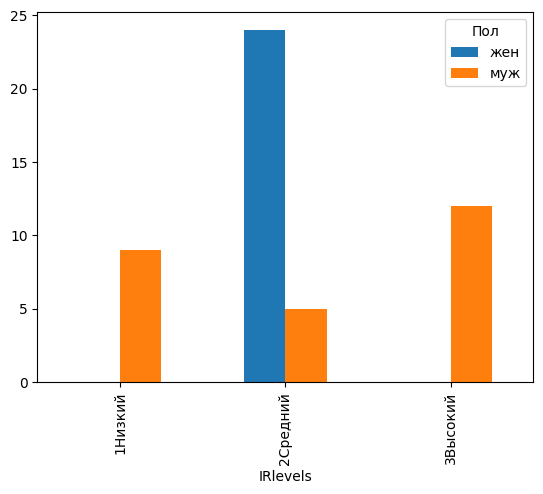

In [17]:
pd.crosstab(index=d['IRlevels'],columns=d['Пол']).plot(kind="bar")

<Axes: xlabel='Интенсреак'>

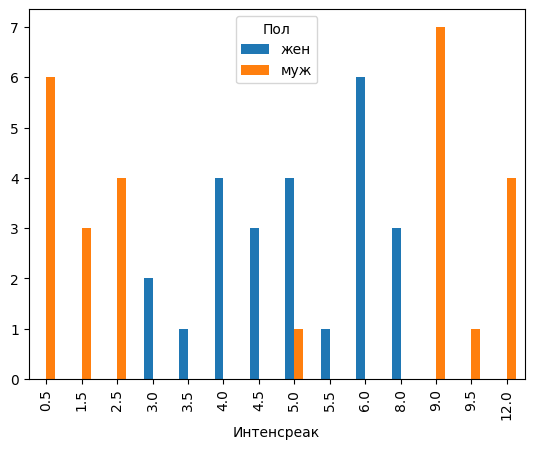

In [18]:
pd.crosstab(index=d['Интенсреак'],columns=d['Пол']).plot(kind="bar")

## 7.6 Меры точек относительного разделения : процентили и квартили

In [26]:
d.head()

,Испытуемый,Пол,Интенсреак,Частпульса,IRlevels
0,"1,00",жен,3.0,72.0,2Средний
1,"2,00",жен,4.0,88.0,2Средний
2,"3,00",жен,4.0,83.0,2Средний
3,"4,00",жен,5.0,86.0,2Средний
4,"5,00",жен,5.0,87.0,2Средний


In [20]:
d.quantile([0.25, 0.5, 0.75], numeric_only=True)

,Интенсреак,Частпульса
0.25,2.625,71.25
0.50,5.000,81.50
0.75,8.000,94.75


In [25]:
d.groupby('Пол', observed=True).quantile([0.25, 0.5, 0.75], numeric_only=True)

Интенсреак  Частпульса
Пол                             
жен 0.25        4.00       78.00
    0.50        5.00       82.50
    0.75        6.00       90.75
муж 0.25        1.50       68.00
    0.50        3.75       78.00
    0.75        9.00       96.50

## 8.4 "Плавный" аналог гистограммы: агрегирующая KDE

In [39]:
d.head()

,Испытуемый,Пол,Интенсреак,Частпульса,IRlevels
0,"1,00",жен,3.0,72.0,2Средний
1,"2,00",жен,4.0,88.0,2Средний
2,"3,00",жен,4.0,83.0,2Средний
3,"4,00",жен,5.0,86.0,2Средний
4,"5,00",жен,5.0,87.0,2Средний


<Axes: ylabel='Frequency'>

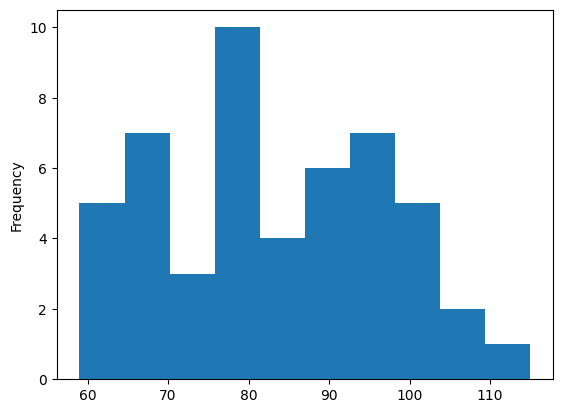

In [27]:
d['Частпульса'].plot.hist()

<Axes: ylabel='Density'>

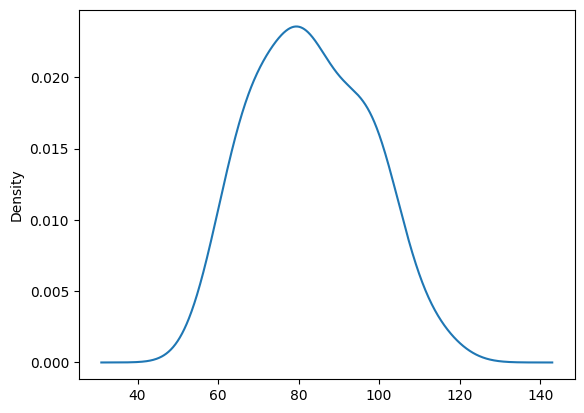

In [28]:
d['Частпульса'].plot.kde()

C:\Users\ilyao\AppData\Local\Temp\ipykernel_12876\3967432380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.plot.hist(column='Частпульса', by='Пол', sharex=True, sharey=True)
C:\Users\ilyao\AppData\Local\Temp\ipykernel_12876\3967432380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.plot.hist(column='Частпульса', by='Пол', sharex=True, sharey=True)
C:\Users\ilyao\AppData\Local\Temp\ipykernel_12876\3967432380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to 

array([<Axes: title={'center': 'жен'}, ylabel='Frequency'>,
       <Axes: title={'center': 'муж'}, ylabel='Frequency'>], dtype=object)

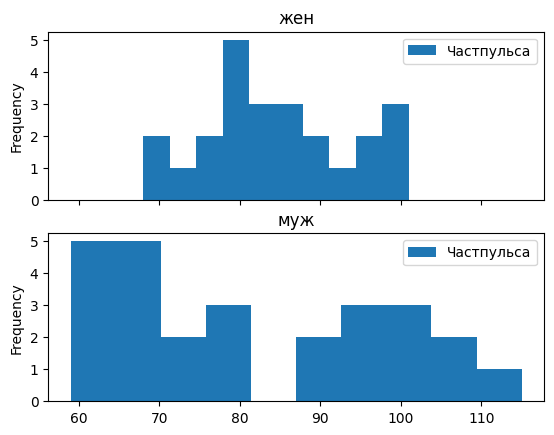

In [33]:
d.plot.hist(column='Частпульса', by='Пол', sharex=True, sharey=True)

Пол
жен    Axes(0.125,0.11;0.775x0.77)
муж    Axes(0.125,0.11;0.775x0.77)
dtype: object

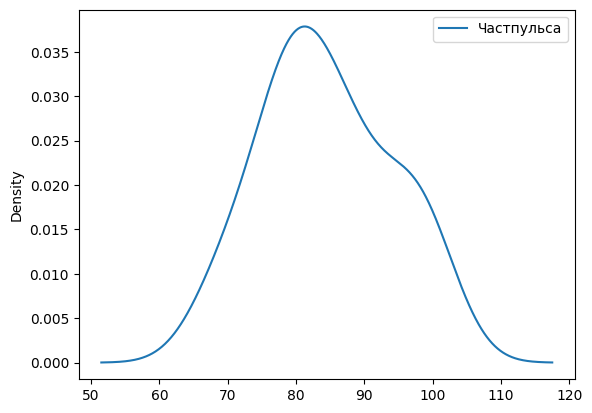

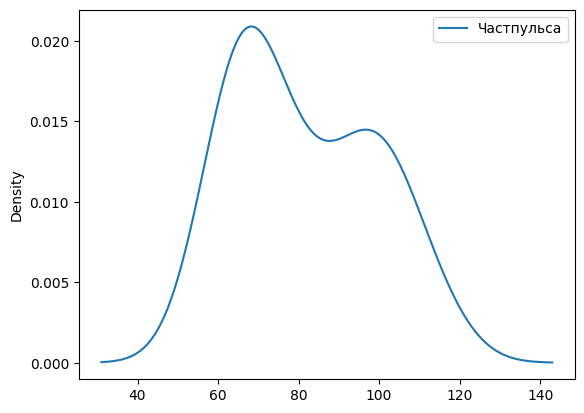

In [36]:
d.groupby('Пол', observed=False).plot.kde(y='Частпульса')

<Axes: ylabel='Density'>

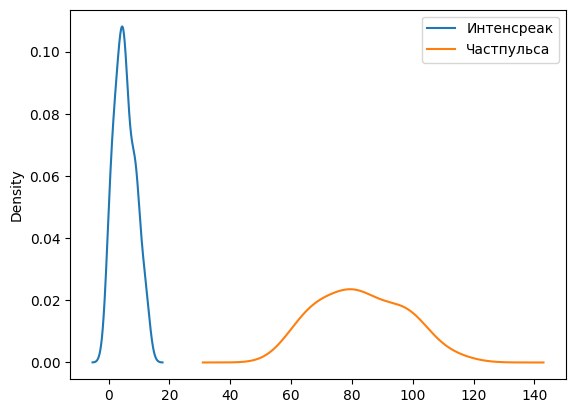

In [37]:
d.plot.kde()

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>], dtype=object)

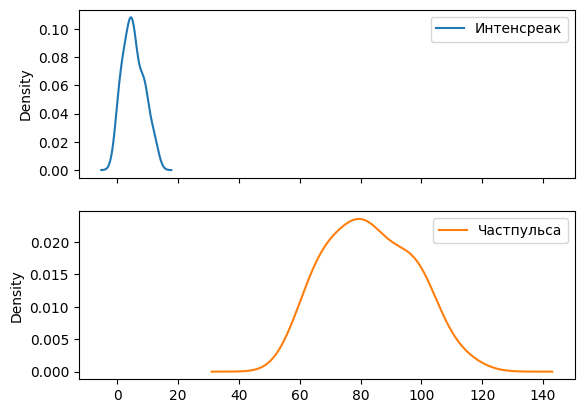

In [38]:
d.plot.kde(subplots=True)

Пол
жен    [Axes(0.125,0.53;0.775x0.35), Axes(0.125,0.11;...
муж    [Axes(0.125,0.53;0.775x0.35), Axes(0.125,0.11;...
dtype: object

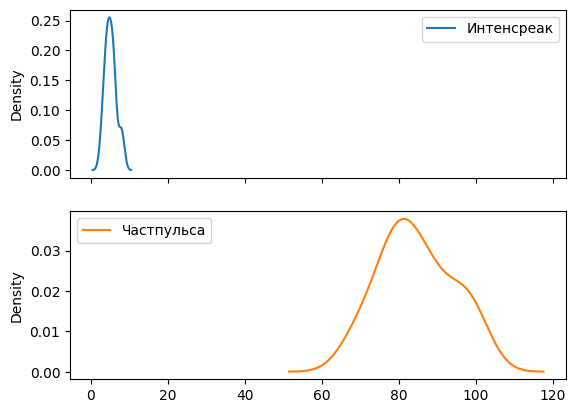

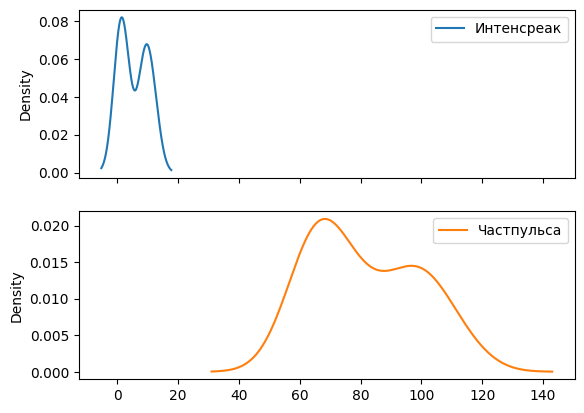

In [40]:
d.groupby('Пол', observed=False).plot.kde(subplots=True)

## 123

# end